# Lab 4 (Beginner Version): UCS, Greedy & A* Search

This notebook walks you through three search algorithms step by step.
You will run code, observe results, and answer short reflection questions.

**No prior search experience required.** Every new concept is explained before you use it.

| Algorithm | Key idea | Optimal? |
|-----------|----------|----------|
| UCS    | Always expand the **cheapest** node so far | Yes |
| Greedy | Always expand the node that **looks closest** to the goal |  No |
| A*     | Combine both: cheapest so far **+** closest to goal | Yes |


In [9]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '../..'))
import fai_viz
print('fai_viz loaded')


fai_viz loaded


## The Romania Road Map

We will find routes between Romanian cities using road distances (km).
The map below shows all cities and roads we can travel.


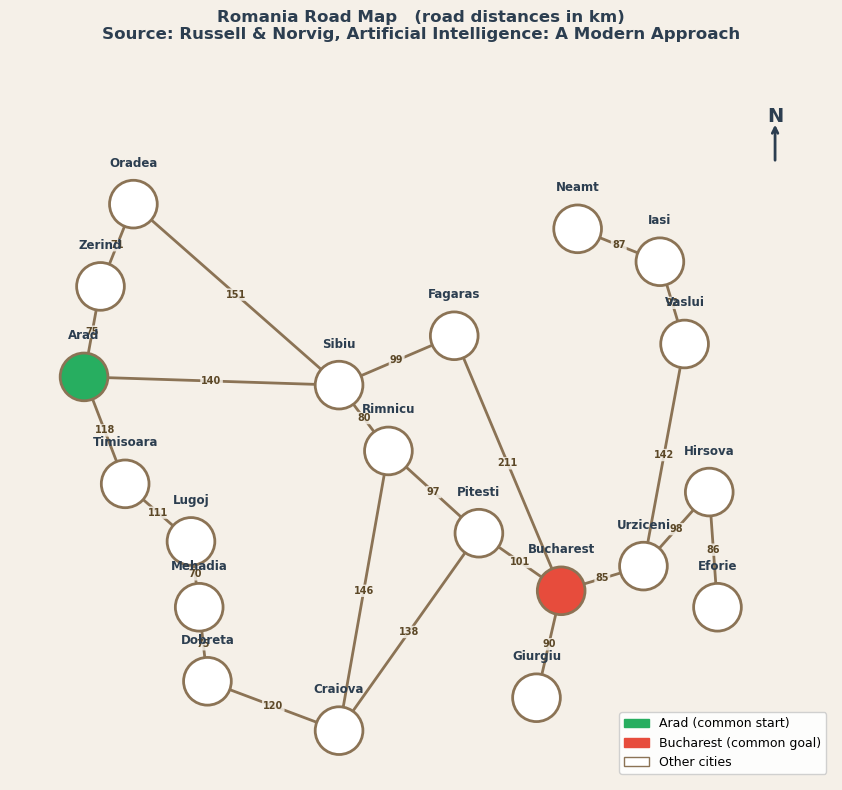

In [10]:
fai_viz.show_romania_map(start_city='Arad', goal_city='Bucharest')


In [ ]:
# ── All helper functions are provided here — run this cell first ──────────────
import math

romania_map = {
    "Arad":      {"Zerind": 75,  "Sibiu": 140, "Timisoara": 118},
    "Zerind":    {"Arad": 75,   "Oradea": 71},
    "Oradea":    {"Zerind": 71,  "Sibiu": 151},
    "Sibiu":     {"Arad": 140,  "Oradea": 151, "Fagaras": 99,  "Rimnicu": 80},
    "Timisoara": {"Arad": 118,  "Lugoj": 111},
    "Lugoj":     {"Timisoara": 111, "Mehadia": 70},
    "Mehadia":   {"Lugoj": 70,  "Dobreta": 75},
    "Dobreta":   {"Mehadia": 75, "Craiova": 120},
    "Rimnicu":   {"Sibiu": 80,  "Craiova": 146, "Pitesti": 97},
    "Fagaras":   {"Sibiu": 99,  "Bucharest": 211},
    "Pitesti":   {"Rimnicu": 97, "Craiova": 138, "Bucharest": 101},
    "Craiova":   {"Dobreta": 120, "Rimnicu": 146, "Pitesti": 138},
    "Bucharest": {"Fagaras": 211, "Pitesti": 101, "Giurgiu": 90, "Urziceni": 85},
    "Giurgiu":   {"Bucharest": 90},
    "Urziceni":  {"Bucharest": 85, "Hirsova": 98, "Vaslui": 142},
    "Hirsova":   {"Urziceni": 98, "Eforie": 86},
    "Eforie":    {"Hirsova": 86},
    "Vaslui":    {"Urziceni": 142, "Iasi": 92},
    "Iasi":      {"Vaslui": 92, "Neamt": 87},
    "Neamt":     {"Iasi": 87},
}

city_coords = {
    "Arad":      (91,  492), "Bucharest": (400, 327), "Craiova":   (253, 288),
    "Dobreta":   (165, 299), "Eforie":    (562, 293), "Fagaras":   (305, 449),
    "Giurgiu":   (375, 270), "Hirsova":   (534, 350), "Iasi":      (473, 506),
    "Lugoj":     (165, 379), "Mehadia":   (168, 339), "Neamt":     (406, 537),
    "Oradea":    (131, 571), "Pitesti":   (320, 368), "Rimnicu":   (233, 411),
    "Sibiu":     (207, 457), "Timisoara": (94,  410), "Urziceni":  (456, 350),
    "Vaslui":    (509, 444), "Zerind":    (108, 531),
}

# ── Problem helpers ───────────────────────────────────────────────────────────
def make_romania_problem(start, goal):
    # A problem is just a dictionary with the starting city, goal city, and the map
    return {'initial': start, 'goal': goal, 'graph': romania_map}

def is_goal(problem, state):
    return state == problem['goal']

def romania_get_actions(problem, state):
    # Returns [(neighbor_city, neighbor_city), ...] — (action, result_state) pairs
    return [(city, city) for city in problem['graph'].get(state, {})]

def romania_action_cost(problem, state, action):
    return problem['graph'].get(state, {}).get(action, float('inf'))

# ── Search node ───────────────────────────────────────────────────────────────
# A node is a plain dict that records where we are and how we got there.
# Structure: {'state': str, 'parent': node | None, 'action': str | None,
#             'cost': float, 'depth': int}
def make_node(state, parent=None, action=None, cost=0, depth=0):
    return {'state': state, 'parent': parent, 'action': action,
            'cost': cost, 'depth': depth}

def reconstruct_path(node):
    # Follow parent pointers back to the start, then reverse
    path = []
    while node:
        path.append(node['state'])
        node = node['parent']
    return list(reversed(path))

def expand(problem, node, get_actions_fn, action_cost_fn):
    children = []
    for action, next_state in get_actions_fn(problem, node['state']):
        step_cost = action_cost_fn(problem, node['state'], action)
        child = make_node(next_state, node, action,
                          node['cost'] + step_cost, node['depth'] + 1)
        children.append(child)
    return children

def is_cycle(node):
    # Returns True if the node's state already appears on the path from the start
    ancestor = node['parent']
    while ancestor:
        if ancestor['state'] == node['state']:
            return True
        ancestor = ancestor['parent']
    return False

# ── General search ────────────────────────────────────────────────────────────
def general_search(problem, queuing_fn, get_actions_fn, action_cost_fn):
    # frontier is a plain list of nodes; we always take from the front (index 0)
    frontier = [make_node(problem['initial'])]
    while True:
        if not frontier:
            return None                 # no solution found
        node = frontier.pop(0)          # take the first node off the frontier
        if is_goal(problem, node['state']):
            return node                 # success!
        children = expand(problem, node, get_actions_fn, action_cost_fn)
        queuing_fn(frontier, children)

def count_expansions(problem, queuing_fn):
    # Same as general_search but also counts how many nodes are expanded
    frontier = [make_node(problem['initial'])]
    count = 0
    while True:
        if not frontier:
            return None, count
        node = frontier.pop(0)          # take the first node off the frontier
        count += 1
        if is_goal(problem, node['state']):
            return node, count
        children = expand(problem, node, romania_get_actions, romania_action_cost)
        queuing_fn(frontier, children)

# ── Heuristic: straight-line distance (SLD) ──────────────────────────────────
def heuristic_sld(state, problem):
    # Compute the straight-line distance from 'state' to the goal city
    # using (x, y) pixel coordinates from the map image
    goal_x, goal_y = city_coords.get(problem['goal'])
    state_x, state_y = city_coords.get(state)
    distance = math.sqrt((goal_x - state_x)**2 + (goal_y - state_y)**2)
    return distance

# ── Queuing functions ─────────────────────────────────────────────────────────
# The ONLY difference between algorithms is how we sort the frontier.

p = make_romania_problem('Arad', 'Bucharest')   # used as context in h and gh queuing fns

def enqueue_by_cost_g(frontier, children):
    # UCS: sort frontier by g(n) = actual cost from start
    for child in children:
        if not is_cycle(child):
            frontier.append(child)
    sorted_frontier = sorted(frontier, key=lambda node: node['cost'])
    frontier.clear()
    frontier.extend(sorted_frontier)

def enqueue_by_cost_h(frontier, children):
    # Greedy: sort frontier by h(n) = estimated cost to goal (SLD)
    for child in children:
        if not is_cycle(child):
            frontier.append(child)
    sorted_frontier = sorted(frontier, key=lambda node: heuristic_sld(node['state'], p))
    frontier.clear()
    frontier.extend(sorted_frontier)

def enqueue_by_cost_gh(frontier, children):
    # A*: sort frontier by f(n) = g(n) + h(n)
    for child in children:
        if not is_cycle(child):
            frontier.append(child)
    sorted_frontier = sorted(frontier, key=lambda node: node['cost'] + heuristic_sld(node['state'], p))
    frontier.clear()
    frontier.extend(sorted_frontier)

print('All helpers loaded. Ready to search!')

## Part 1: How the Three Algorithms Work

All three algorithms use the **same** `general_search` loop.
The **only** difference is the queuing function — how they decide which node to expand next.

```
general_search repeats:
  1. Take the first node off the frontier
  2. If it is the goal → done!
  3. Otherwise: expand it (find neighbors), add them to the frontier
  4. Re-sort the frontier according to the queuing function
```

### UCS — sort by g(n)  `enqueue_by_cost_g`
`g(n)` = total road cost from start to node `n`.
UCS always expands the cheapest node first → **guaranteed optimal**.

### Greedy — sort by h(n)  `enqueue_by_cost_h`
`h(n)` = straight-line distance (SLD) from node `n` to the goal.
Greedy races toward the goal but **ignores cost already paid** → may miss the cheapest path.

### A* — sort by f(n) = g(n) + h(n)  `enqueue_by_cost_gh`
Combines both: actual cost paid + estimated cost remaining.
**Optimal** when `h(n)` never overestimates (admissible heuristic).

---
**SLD is admissible** because straight-line distance ≤ actual road distance (you can't
drive shorter than a straight line).


## Part 2: Worked Example — Arad → Bucharest

Let's run all three algorithms and compare their results before you write any code.


In [ ]:
# Worked example — run all three and see the difference
p = make_romania_problem('Arad', 'Bucharest')

ucs_node,    ucs_exp    = count_expansions(p, enqueue_by_cost_g)
greedy_node, greedy_exp = count_expansions(p, enqueue_by_cost_h)
astar_node,  astar_exp  = count_expansions(p, enqueue_by_cost_gh)

print('Algorithm  Path                                              Cost   Expansions')
print('-' * 80)
print(f"UCS        {' -> '.join(reconstruct_path(ucs_node)):50s} {ucs_node['cost']:4d}   {ucs_exp}")
print(f"Greedy     {' -> '.join(reconstruct_path(greedy_node)):50s} {greedy_node['cost']:4d}   {greedy_exp}")
print(f"A*         {' -> '.join(reconstruct_path(astar_node)):50s} {astar_node['cost']:4d}   {astar_exp}")
print()
print('Notice:')
print('  - UCS and A* both find cost 418 (optimal).')
print('  - Greedy finds a different (more expensive) path — it was misled by SLD.')
print('  - A* expands fewer nodes than UCS because h(n) guides it toward Bucharest.')


## Part 3: Exercises

Work through each exercise in order. Each one builds on the previous.

---
## Exercise 1 — Run UCS on Two Routes 

**Goal:** practice calling `general_search` with the right queuing function.

UCS uses `enqueue_by_cost_g`. It always finds the cheapest path.


In [ ]:
# ── Exercise 1 ────────────────────────────────────────────────────────────────
# Run UCS on each route and print the path + cost.
# Hint: call general_search(problem, queuing_fn, romania_get_actions, romania_action_cost)

routes = [
    ('Arad',     'Bucharest'),
    ('Timisoara','Bucharest'),
]

for start, goal in routes:
    # YOUR CODE: 1. make a problem 2. call general_search with enqueue_by_cost_g
    node = None     # ← replace None with your general_search(...) call

    if node:
        path = reconstruct_path(node)
        print(f"{start} → {goal}")
        print(f"  Path: {' -> '.join(path)}")
        print(f"  Cost: {node['cost']} km")
        print()


## Exercise 2 — Compare UCS, Greedy, and A* 

Run all three algorithms on one route and compare:
- Do they all find the same path?
- Do they all find the same cost?
- Which one expands the fewest nodes?

**Route:** Timisoara → Bucharest


In [ ]:
# ── Exercise 2 ────────────────────────────────────────────────────────────────
prob = make_romania_problem('Timisoara', 'Bucharest')

# Step 1: run UCS (already done for you as an example)
ucs_node, ucs_exp = count_expansions(prob, enqueue_by_cost_g)
print(f"UCS    cost={ucs_node['cost']:4d}  expansions={ucs_exp:3d}  path: {' -> '.join(reconstruct_path(ucs_node))}")

# Step 2: run Greedy — YOUR CODE
greedy_node = None   # ← replace with greedy search
if greedy_node:
    print(f"Greedy cost={greedy_node['cost']:4d}                path: {' -> '.join(reconstruct_path(greedy_node))}")

# Step 3: run A* — YOUR CODE
astar_node = None    # ← replace with A* search
if astar_node:
    print(f"A*     cost={astar_node['cost']:4d}                path: {' -> '.join(reconstruct_path(astar_node))}")

print()
# Reflection — answer in comments:
# Q1: Does Greedy find the same cost as UCS?
# Q2: Does A* find the same cost as UCS?
# Q3: Looking at the paths, why do you think Greedy took a different route?


## Exercise 3 — Change the Goal City 

`heuristic_sld` computes SLD to **whatever city is in `problem['goal']`**.
So the same heuristic function works for any goal — you just need a new problem and a new queuing function.

**Task:** find the route Arad → Iasi using all three algorithms.

The queuing functions `enqueue_by_cost_h` and `enqueue_by_cost_gh` capture `p`
(which points to Bucharest). For Iasi you need new functions that use `p_iasi` instead.

A template for the Greedy function is provided. Complete it, then write the A* version.


In [ ]:
# ── Exercise 3 ────────────────────────────────────────────────────────────────
p_iasi = make_romania_problem('Arad', 'Iasi')

# Greedy queuing function for Iasi (template provided — fill in the blank)
def enqueue_greedy_iasi(frontier, children):
    for child in children:
        if not is_cycle(child):
            frontier.append(child)
    sorted_frontier =  # YOUR CODE: sort by heuristic_sld(node['state'], _____) replace _____ with the correct problem variable
    frontier.clear()
    frontier.extend(sorted_frontier)

# A* queuing function for Iasi — YOUR CODE (follow the same pattern as enqueue_greedy_iasi)
def enqueue_astar_iasi(frontier, children):
    for child in children:
        if not is_cycle(child):
            frontier.append(child)
    sorted_frontier = # Your code : sort by node['cost'] + heuristic_sld(node['state'], _____)
    frontier.clear()
    frontier.extend(sorted_frontier)

# Run all three algorithms
ucs_node    = general_search(p_iasi, enqueue_by_cost_g,    romania_get_actions, romania_action_cost)
greedy_node = general_search(p_iasi, enqueue_greedy_iasi,  romania_get_actions, romania_action_cost)
astar_node  = general_search(p_iasi, enqueue_astar_iasi,   romania_get_actions, romania_action_cost)

print(f"UCS    cost={ucs_node['cost']:4d}  path: {' -> '.join(reconstruct_path(ucs_node))}")
if greedy_node:
    print(f"Greedy cost={greedy_node['cost']:4d}  path: {' -> '.join(reconstruct_path(greedy_node))}")
if astar_node:
    print(f"A*     cost={astar_node['cost']:4d}  path: {' -> '.join(reconstruct_path(astar_node))}")


## Exercise 4 — What Happens When h(n) = 0? 

An admissible heuristic must **never overestimate** the true remaining cost.
`h(n) = 0` satisfies this trivially (0 never overestimates) — but it gives A* **no information**.

When `h(n) = 0`:  `f(n) = g(n) + 0 = g(n)` → A* sorts only by actual cost → identical to UCS!

When `h(n) = SLD`: `f(n) = g(n) + h(n)` → A* uses the heuristic to prefer nodes closer to the goal.

**Task:** implement `heuristic_zero`, write the corresponding A* queuing function,
and compare how many nodes each heuristic causes A* to expand.


In [ ]:
# ── Exercise 4 ────────────────────────────────────────────────────────────────

# Step 1: implement the zero heuristic
def heuristic_zero(state, problem):
    # YOUR CODE: 
    # This heuristic is admissible (0 never overestimates) but gives no directional info
    pass

# Step 2: write A* with the zero heuristic
p = make_romania_problem('Arad', 'Bucharest')

def enqueue_astar_zero(frontier, children):
    for child in children:
        if not is_cycle(child):
            frontier.append(child)
    sorted_frontier = # YOUR CODE: sort by node['cost'] + heuristic_zero()
    frontier.clear()
    frontier.extend(sorted_frontier)

# Step 3: compare expansions
node_zero, exp_zero = count_expansions(p, enqueue_astar_zero)
node_sld,  exp_sld  = count_expansions(p, enqueue_by_cost_gh)

print(f"A* with h=0  : cost={node_zero['cost'] if node_zero else '?'}  expansions={exp_zero}")
print(f"A* with h=SLD: cost={node_sld['cost']  if node_sld  else '?'}  expansions={exp_sld}")
print()

# Step 4: fill in your answer
# When h(n) = 0, A* is identical to _________ .
# Explanation: ...
# A*(h=SLD) expands fewer nodes because: ...


## Exercise 5 — Choosing the Right Algorithm

### Part A: Pick the Algorithm

For each scenario, choose the best algorithm: **BFS**, **UCS**, **Greedy**, or **A***.
Write your answer and a short reason in the comment.

| # | Scenario | Think about... |
|---|----------|----------------|
| 1 | Every road costs the same. You want the fewest stops. | Which algorithm optimises hops? |
| 2 | You have a good heuristic and must find the cheapest path. | Which is optimal + uses heuristic? |
| 3 | You have no heuristic. You must guarantee the cheapest path. | Which is optimal without h(n)? |
| 4 | Approximate is fine. You want the answer as fast as possible. | Which ignores cost and races ahead? |

### Part B: Why Does Greedy Fail?

Print both the UCS and Greedy paths for **Oradea → Eforie**.
Then explain in a comment why Greedy chose a more expensive route.


In [ ]:
# ── Exercise 5 ────────────────────────────────────────────────────────────────

# Part A: write your answer after each →
# 1. Same cost, fewest stops   →
# 2. Good heuristic, optimal   →
# 3. No heuristic, optimal     →
# 4. Approximate, fastest      →

print('Part A: see comments above')
print()

# Part B: compare UCS vs Greedy on Oradea → Eforie
prob = make_romania_problem('Oradea', 'Eforie')

# YOUR CODE: run UCS and Greedy
ucs_node    = None   # ← replace with general_search(...)
greedy_node = None   # ← replace with general_search(...)

if ucs_node and greedy_node:
    print(f"UCS    cost={ucs_node['cost']:4d}  path: {' -> '.join(reconstruct_path(ucs_node))}")
    print(f"Greedy cost={greedy_node['cost']:4d}  path: {' -> '.join(reconstruct_path(greedy_node))}")
    print()

# YOUR EXPLANATION:
# Greedy was misled because ...


## Summary

| Algorithm | Sorts frontier by | g(n)? | h(n)? | Optimal? | Use when |
|-----------|-------------------|-------|-------|----------|----------|
| BFS       | insertion order   | No    | No    | (hops)   | all edges equal weight |
| UCS       | `g(n)` — actual cost | Yes | No  |  Yes  | no heuristic, need cheapest |
| Greedy    | `h(n)` — SLD to goal | No  | Yes |  No   | speed > accuracy |
| **A***    | `g(n) + h(n)`     | Yes   | Yes   | Yes   | **default choice** |

**Golden rule:** A* with an admissible heuristic is always optimal.
A heuristic is admissible when it never overestimates — SLD qualifies because straight-line ≤ road distance.


In [ ]:
# Visual summary: path cost and nodes expanded for each algorithm
p = make_romania_problem('Arad', 'Bucharest')

# count_expansions returns both the result node AND how many nodes were expanded
ucs_n,    ucs_exp    = count_expansions(p, enqueue_by_cost_g)
greedy_n, greedy_exp = count_expansions(p, enqueue_by_cost_h)
astar_n,  astar_exp  = count_expansions(p, enqueue_by_cost_gh)

fai_viz.plot_algorithm_comparison(
    ['UCS', 'Greedy', 'A*'],
    [ucs_n['cost'], greedy_n['cost'], astar_n['cost']],
    [ucs_exp,       greedy_exp,       astar_exp])